In [3]:
# pip install langfuse

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [13]:
from langfuse import get_client,propagate_attributes,Evaluation

langfuse = get_client()

if not langfuse.auth_check():
    raise RuntimeError("Check that your Langfuse project keys match the configured region.")



## 1. Building the Graph/agent

In [3]:
# build simple Langgraph based agent
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.runnables import RunnableConfig
from langchain_openai import ChatOpenAI



/Users/rahultiwari/Documents/02_Freelancing/coding_ninja_fresh/dummy-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import os

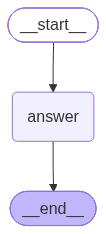

In [7]:
MODEL = os.environ.get("OPENAI_MODEL", "gpt-4o")
llm = ChatOpenAI(model=MODEL, temperature=0.2, timeout=30, max_retries=1)


class ChatState(TypedDict):
    messages: Annotated[list, add_messages]

def chatbot(state: ChatState, config: RunnableConfig):
    # Forward the graph config so the model inherits tracing callbacks.
    reply = llm.invoke(state["messages"], config=config)
    return {"messages": [reply]}

builder = StateGraph(ChatState)
builder.add_node("answer", chatbot)
builder.add_edge(START, "answer")
builder.add_edge("answer", END)
simple_graph = builder.compile()
simple_graph

In [11]:
## smallest traceable graph : trace
from langfuse.langchain import CallbackHandler


basic_handler = CallbackHandler()
basic_result =  simple_graph.invoke(
    {"messages": [HumanMessage(content="tell me how LLM works")]},
    config={"callbacks": [basic_handler]},
)



In [10]:
basic_handler.last_trace_id

'ec25e82f8ad2de20aeb5444242fc8656'

In [12]:
basic_handler.last_trace_id

'1dc1f7dd6ba3e31ab74d4b9267e42454'

In [15]:
named_handler = CallbackHandler()


with propagate_attributes(
    trace_name="lesson-chat", user_id="demo-student", session_id="lesson-session",
    tags=["teaching-lab", "basic"], metadata={"lesson": "named-tracing"},
):
    named_result = simple_graph.invoke(
        {"messages": [HumanMessage(content="tell me how LLM works for 10 years kid")]},
        config={"callbacks": [named_handler], "run_name": "explain-trace-and-metric"},
    )


In [16]:
named_handler = CallbackHandler()


with propagate_attributes(
    trace_name="lesson-chat", user_id="rahul-demo", session_id="dummy-session",
    tags=["teaching-lab", "basic"], metadata={"lesson": "named-tracing"},
):
    named_result = simple_graph.invoke(
        {"messages": [HumanMessage(content="tell me how LLM works for 10 years kid")]},
        config={"callbacks": [named_handler], "run_name": "explain-trace-and-metric"},
    )


# example 2

## Simple RAG solution --> track it in our langfuse

In [17]:
import re
import time
import math
from datetime import datetime, timezone, timedelta

POLICIES = {
    "refund": "POLICY-R1: Refunds are available within 30 days of purchase with a receipt.",
    "shipping": "POLICY-S1: Standard shipping takes 3 to 5 business days.",
    "password": "POLICY-A1: Reset your password from the account sign-in page using Forgot password.",
}

BASE_PROMPT = (
    "You are a support assistant for a fictional teaching store. "
    "Answer using only the supplied policy context. Cite its POLICY identifier. "
    "If no policy answers the question, say 'I do not know from the available policies.' "
    "Keep the answer under 80 words."
)


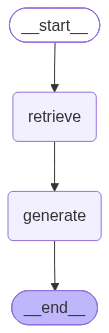

In [18]:
class SupportState(TypedDict, total=False):
    question: str
    context: str
    document_ids: list[str]
    answer: str
    usage: dict
    fail_demo: bool
    system_prompt: str

def retrieve(state: SupportState):
    # A visible application failure is different from a background export failure.
    if state.get("fail_demo"):
        raise RuntimeError("Intentional demo: policy store unavailable")
    with langfuse.start_as_current_observation(name="policy-lookup", as_type="retriever") as span:
        question = state["question"].lower()
        hits = [text for keyword, text in POLICIES.items() if keyword in question]
        ids = [text.split(":", 1)[0] for text in hits]
        context = "\n".join(hits) or "No matching policy."
        span.update(input=state["question"], output={"document_ids": ids, "context": context})
        return {"context": context, "document_ids": ids}

def generate(state: SupportState, config: RunnableConfig):
    # Keep context and the user question separate from the system instruction.
    messages = [
        SystemMessage(content=state.get("system_prompt", BASE_PROMPT)),
        HumanMessage(content=f"Policy context:\n{state['context']}\n\nQuestion: {state['question']}"),
    ]
    response = llm.invoke(messages, config=config)
    return {"answer": response.content, "usage": response.usage_metadata or {}}

support_builder = StateGraph(SupportState)
support_builder.add_node("retrieve", retrieve)
support_builder.add_node("generate", generate)
support_builder.add_edge(START, "retrieve")
support_builder.add_edge("retrieve", "generate")
support_builder.add_edge("generate", END)
support_graph = support_builder.compile()
support_graph

In [19]:

request_records = []
def run_support(question, *, label="support-request", fail_demo=False, system_prompt=BASE_PROMPT):
    handler = CallbackHandler()
    started = time.perf_counter()
    record = {"question": question, "ok": False, "answer": "", "usage": {}}

    with langfuse.start_as_current_observation(name="support-http-request", input=question) as root:
        record["trace_id"] = root.trace_id
        with propagate_attributes(
            trace_name=label, user_id="demo-student", session_id="support-lesson",
            tags=["teaching-lab", "support"], metadata={"model": MODEL, "app_version": "lesson-v1"},
        ):
            try:
                result = support_graph.invoke(
                    {"question": question, "fail_demo": fail_demo, "system_prompt": system_prompt},
                    config={"callbacks": [handler], "run_name": "support-workflow"},
                )
                record.update(ok=True, answer=result["answer"], usage=result["usage"])
                root.update(output=result["answer"])
            except Exception as exc:
                record["error"] = str(exc)
                root.update(level="ERROR", status_message=str(exc))
            finally:
                record["latency_s"] = time.perf_counter() - started

    return record


In [22]:
failure_record = run_support("who is pm Of india?", label="support-failure", fail_demo=False)


In [21]:
failure_record

{'question': 'What is your refund policy?',
 'ok': True,
 'answer': 'Refunds are available within 30 days of purchase with a receipt. [POLICY-R1]',
 'usage': {'input_tokens': 91,
  'output_tokens': 20,
  'total_tokens': 111,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 0}},
 'trace_id': '7b280b30902d5b2656602874e5f5cb19',
 'latency_s': 1.3755347090191208}

In [23]:
failure_record

{'question': 'who is pm Of india?',
 'ok': True,
 'answer': 'I do not know from the available policies.',
 'usage': {'input_tokens': 76,
  'output_tokens': 9,
  'total_tokens': 85,
  'input_token_details': {'audio': 0, 'cache_read': 0},
  'output_token_details': {'audio': 0, 'reasoning': 0}},
 'trace_id': 'fcb9c9dc4c89339a75923b2acc1b8239',
 'latency_s': 1.2859440839965828}